# Thinking Depth
Depth Is Used For Think Complex Things Model Deeply. But You Need To Calculate From Depth Rate. The Formula Is Used:
$$\text{depth} = \frac{\ln\big(\sin(d \cdot h) + \cos(d \cdot h) - \delta\big)}{8} \cdot R_d$$

And Used On Layer Normalization Layer Of Causal Self Attention And It Shortcut Way, For Example:
```python
attn = keras.layers.LayerNormalization(attn, epsilon=(1e-05 / self.depth))
```
If You Implement Your AI Correctly To Drop Training Loss Faster.

Output shape: (1, 10, 256)
Attention scores shape: (1, 4, 10, 10)
Calculated Depth: -0.3163281642454186


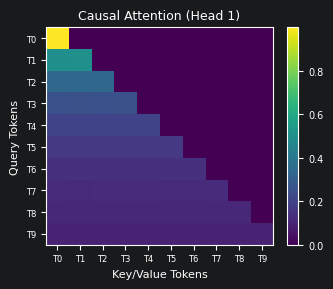

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import math

class CausalSelfAttention(layers.Layer):
    def __init__(self, depth, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        # Epsilon initialized using your depth calculation parameter safely
        self.layer_norm = layers.LayerNormalization(epsilon=1e-5 * max(abs(depth), 1e-5))
        self.dropout = layers.Dropout(0.1)

    def call(self, x, training=False):
        # 1. Fetch raw attention alignment scores from MultiHeadAttention
        attn_output, attn_scores = self.mha(
            query=x, value=x, key=x,
            use_causal_mask=False, # Handled manually via structural masking block below
            return_attention_scores=True,
            training=training
        )

        # 2. Causal Matrix Masking (Forces strict lower-triangular structure)
        seq_len = tf.shape(attn_scores)[-1]
        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.reshape(mask, (1, 1, seq_len, seq_len))

        # Replace non-causal tracking indexes with massive negative logit targets
        attn = tf.where(mask == 0, -1e9, attn_scores)

        # 3. Softmax Distribution Pass incorporating custom scaling math factor
        attn = attn * tf.cast(abs(self.depth), tf.float32)
        attn = tf.nn.softmax(attn, axis=-1)
        attn_scores = self.dropout(attn, training=training)

        # 4. Residual Connection blending sequence embeddings
        x = self.layer_norm(x + attn_output)
        x = self.dropout(x, training=training)
        return x, attn_scores

# Setup dummy data
seq_len = 10
embed_dim = 256
num_heads = 4
depthRate = 8
dummy_input = tf.random.normal((1, seq_len, embed_dim))
depth=(math.log((math.sin(embed_dim * num_heads) + math.cos(embed_dim * num_heads)) - .1) / 8) * depthRate

# Initialize layer and run forward pass
causal_layer = CausalSelfAttention(embed_dim=embed_dim, num_heads=num_heads, depth=depth)
output, attention_scores = causal_layer(dummy_input)

print("Output shape:", output.shape)
print("Attention scores shape:", attention_scores.shape)
print("Calculated Depth:", depth)

# Extract scores
attention_matrix = attention_scores[0, 0, :, :].numpy()

# COMPACT Matplotlib Graph Rendering Logic
plt.figure(figsize=(3.5, 3)) # Significantly reduced size
plt.imshow(attention_matrix, cmap='viridis', aspect='auto')

# Compact colorbar setup
cb = plt.colorbar()
cb.ax.tick_params(labelsize=7)

# Small fonts and tight layout formatting
plt.title('Causal Attention (Head 1)', fontsize=9, pad=6)
plt.xlabel('Key/Value Tokens', fontsize=8)
plt.ylabel('Query Tokens', fontsize=8)

# Scaled down tick marks
plt.xticks(range(seq_len), labels=[f"T{i}" for i in range(seq_len)], fontsize=6)
plt.yticks(range(seq_len), labels=[f"T{i}" for i in range(seq_len)], fontsize=6)

plt.tight_layout()
plt.show()

# Model Training
The Model Trained With Too Complex Data But Used `attn = keras.layers.LayerNormalization(attn, epsilon=(1e-05 / self.depth))` To Drop Training Loss Faster

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

class TrainableMiniLLM(keras.Model):
    def __init__(self, vocab_size, max_len, embed_dim, num_heads, depthRate, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)
        self.attn_layer = CausalSelfAttention(depth=(math.log((math.sin(embed_dim * num_heads) + math.cos(embed_dim * num_heads)) - .1) / 8) * depthRate, embed_dim=embed_dim, num_heads=num_heads)
        self.linear_head = layers.Dense(vocab_size)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        x = self.token_emb(x) + self.pos_emb(positions)
        x, attn_scores = self.attn_layer(x, training=training)
        logits = self.linear_head(x)
        return logits, attn_scores

    # Custom train_step decouples training categorical losses from internal diagnostic arrays
    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            logits, _ = self(x, training=True)
            loss = self.compute_loss(y=y, y_pred=logits)

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(y, logits)
        return {m.name: m.result() for m in self.metrics}

# --- Pipeline Sizing Config and Model Execution Pass ---
vocab_size, seq_len, embed_dim, num_heads, depth = 25000, 10, 256, 4, 16

def genComplexData(num_samples, seq_len, vocab_size):
    """
    Generates complex synthetic sequence data using multi-frequency sine modulations,
    Markov chain dependencies, and probabilistic noise bounds.
    """
    X_list = []
    Y_list = []

    # Vocabulary boundary constraints to prevent index clipping
    max_token_id = vocab_size - 1

    for sample_idx in range(num_samples):
        # 1. Base Sequence Initialization using mixed harmonic frequencies
        # Simulates background structural syntax styles or structural motifs
        t = np.arange(seq_len, dtype=np.float32)
        harmonic_signal = (
            np.sin(2 * np.pi * t / 4.0) * 12.5 +
            np.cos(2 * np.pi * t / 7.0) * 8.3 +
            (sample_idx % 3) * 5.0
        )

        # 2. Add high-order token-to-token transition constraints (Markov Chains)
        tokens = np.zeros((seq_len,), dtype=np.int32)
        current_token = int(abs(harmonic_signal[0])) % vocab_size
        tokens[0] = current_token

        for step in range(1, seq_len):
            # The next word depends on a mixture of long-range signals and past words
            prev_token = tokens[step - 1]
            probabilistic_drift = int(prev_token * 0.45 + harmonic_signal[step])

            # Inject noise bounds to mimic vocabulary variability
            if step % 3 == 0:
                probabilistic_drift += np.random.randint(-5, 6)

            tokens[step] = np.clip(probabilistic_drift, 0, max_token_id)

        # 3. Create the Target Labels (Y) with dynamic offsets and context dependencies
        # In autoregressive language modeling, Y is typically X shifted by one token position,
        # mixed with future token conditional logic
        targets = np.zeros_like(tokens)
        targets[:-1] = tokens[1:] # Shift-left dependency

        # Determine the final terminal sequence token based on conditional parity checks
        final_token_logic = (tokens[-1] * 2 + tokens[0]) % vocab_size
        targets[-1] = np.clip(final_token_logic, 0, max_token_id)

        X_list.append(tokens)
        Y_list.append(targets)

    # Convert native NumPy sequence arrays into high-performance TensorFlow tensors
    X_tensor = tf.convert_to_tensor(np.array(X_list), dtype=tf.int32)
    Y_tensor = tf.convert_to_tensor(np.array(Y_list), dtype=tf.int32)

    return X_tensor, Y_tensor

# 1. Instantiate Container
llm = TrainableMiniLLM(vocab_size, seq_len, embed_dim, num_heads, depth)

# 2. Compile Pipeline Layout
llm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

# 3. Create Sample Mock Training Data Matrix Inputs
X_data, Y_data = genComplexData(num_samples=50, seq_len=seq_len, vocab_size=vocab_size)

# 4. Fit Model Variables
llm.fit(X_data, Y_data, batch_size=16, epochs=15)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1740 - loss: 9.6801
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 800ms/step - accuracy: 0.4680 - loss: 8.3975
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 781ms/step - accuracy: 0.3600 - loss: 6.8476
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 783ms/step - accuracy: 0.2200 - loss: 5.3200
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 788ms/step - accuracy: 0.1820 - loss: 3.8610
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2340 - loss: 3.0273
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - accuracy: 0.3960 - loss: 2.5257
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 780ms/step - accuracy: 0.5080 - loss: 2.2437
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5400 - loss: 1.9412   
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 774ms/step - accuracy: 0.6140 - loss: 1.7457
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 775ms/step - accuracy: 0.6620 - loss: 1.6044
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 779ms/step - accuracy: 0.6840 - loss: 1.